Dataset overview


Creat notebook

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv("../data/mobile_data.csv")

Understand the Dataset


In [94]:
df.head()

,brand,model,price,ram_gb,storage_gb,rating
0,Apple,iPhone 13,2299,4,128,4.7
1,Apple,iPhone 14,2799,6,128,4.6
2,Apple,iPhone 15,3299,6,128,4.8
3,Apple,iPhone 15 Pro,4299,8,256,4.9
4,Samsung,Galaxy S22,2199,8,128,4.5


In [80]:
df.shape

(18, 6)

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   brand       18 non-null     str    
 1   model       18 non-null     str    
 2   price       18 non-null     int64  
 3   ram_gb      18 non-null     int64  
 4   storage_gb  18 non-null     int64  
 5   rating      18 non-null     float64
dtypes: float64(1), int64(3), str(2)
memory usage: 996.0 bytes


In [82]:
df.describe()

,price,ram_gb,storage_gb,rating
count,18.000000,18.000000,18.000000,18.00000
mean,2687.888889,9.222222,241.777778,4.65000
std,970.075127,3.370382,138.062030,0.17905
min,799.000000,4.000000,128.000000,4.30000
25%,2224.000000,8.000000,128.000000,4.52500
50%,2599.000000,8.000000,256.000000,4.65000
75%,3274.000000,12.000000,256.000000,4.80000
max,4499.000000,16.000000,512.000000,4.90000


Check missing value


In [83]:
df.isnull().sum()

brand         0
model         0
price         0
ram_gb        0
storage_gb    0
rating        0
dtype: int64

Check duplicates

In [84]:
df.duplicated().sum()

np.int64(0)

Price Analysis:

Basic statistics

In [85]:
df["price"].mean()

np.float64(2687.8888888888887)

In [86]:
df["price"].median()

np.float64(2599.0)

In [87]:
df["price"].min()

np.int64(799)

In [88]:
df["price"].max()

np.int64(4499)

Find the cheapest phone



In [89]:
df.loc[df["price"].idxmin()]

brand                Xiaomi
model         Redmi Note 12
price                   799
ram_gb                    6
storage_gb              128
rating                  4.3
Name: 8, dtype: object

Find the expensive phone

In [90]:
df.loc[df["price"].idxmax()]

brand                  Samsung
model         Galaxy S24 Ultra
price                     4499
ram_gb                      12
storage_gb                 512
rating                     4.9
Name: 7, dtype: object

Price Distribution


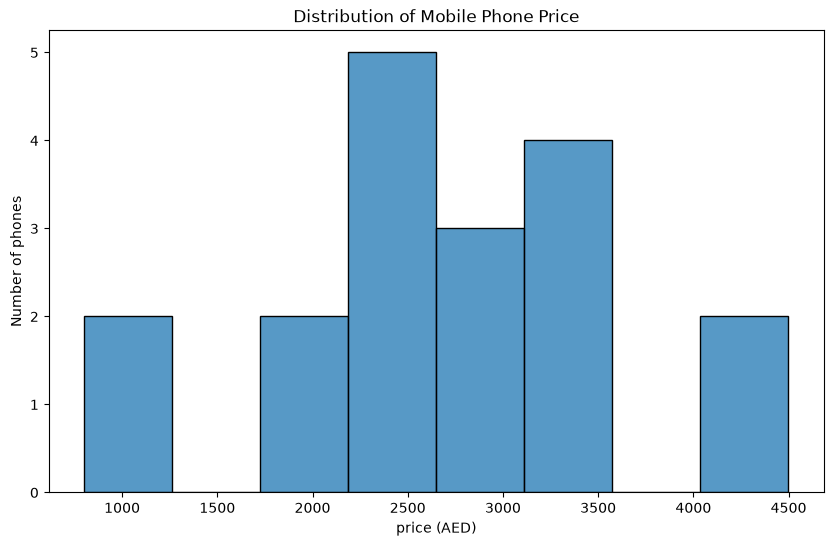

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="price",
    bins=8
)
plt.title("Distribution of Mobile Phone Price")
plt.xlabel("price (AED)")
plt.ylabel("Number of phones")

plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\price_distribution.png")
plt.show()

### Finding
Most Phones in dataset are concentrated in the mid_range 
price categories, while a smaller number of Phones are high.

Brand Analyist


In [ ]:
df["brand"].value_counts()

brand
Apple      4
Samsung    4
Xiaomi     4
OnePlus    3
Google     3
Name: count, dtype: int64

Visualization


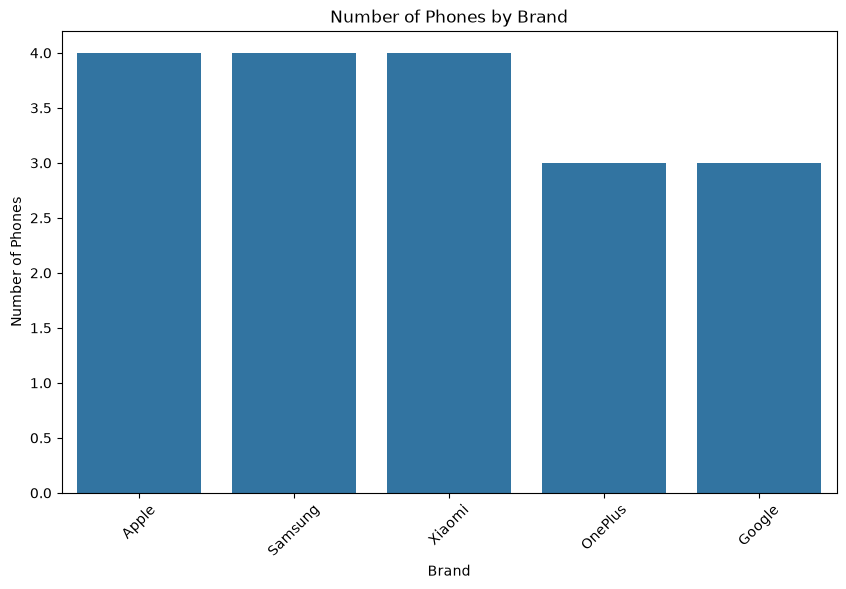

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="brand"
)
plt.title("Number of Phones by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Phones")
plt.xticks(rotation=45)
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\phone_by_brand.png")
plt.show()


Average price by brand

In [ ]:
df.groupby("brand")["price"].mean().sort_values(ascending=False)

brand
Apple      3174.000000
Samsung    3149.000000
Google     2665.666667
OnePlus    2432.333333
Xiaomi     1949.000000
Name: price, dtype: float64

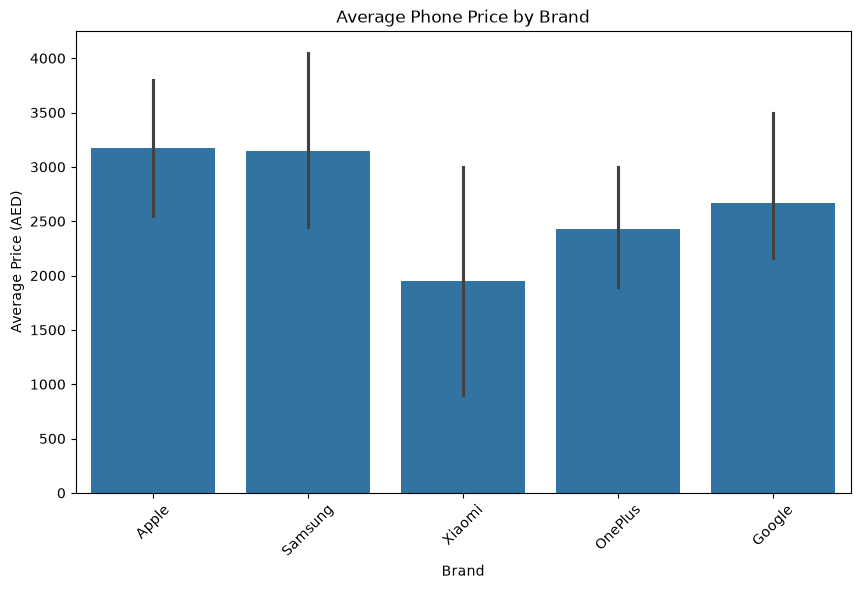

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="brand",
    y="price"
)

plt.title("Average Phone Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (AED)")

plt.xticks(rotation=45)
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\by_brand.png")
plt.show()

### Finding
Apple and Sumsung have relatively high average price, xiomi genrally offers lower_priced devices.


Ram Distribution

In [ ]:
df["ram_gb"].value_counts().sort_index()

ram_gb
4     1
6     3
8     8
12    4
16    2
Name: count, dtype: int64

RAM vs Price


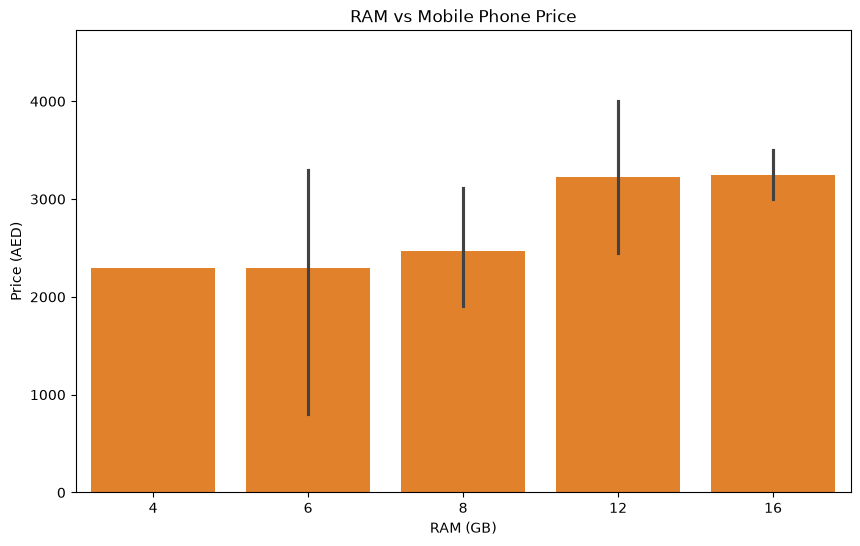

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="ram_gb",
    y="price"
)
sns.barplot(data=df,
            x="ram_gb", y="price")
sns.axes_style("whitegrid")
plt.title("RAM vs Mobile Phone Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (AED)")
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\ram_vs_price.png")
plt.show()

Storage vs Price


In [ ]:
df["storage_gb"].value_counts().sort_index()

storage_gb
128    8
256    7
512    3
Name: count, dtype: int64

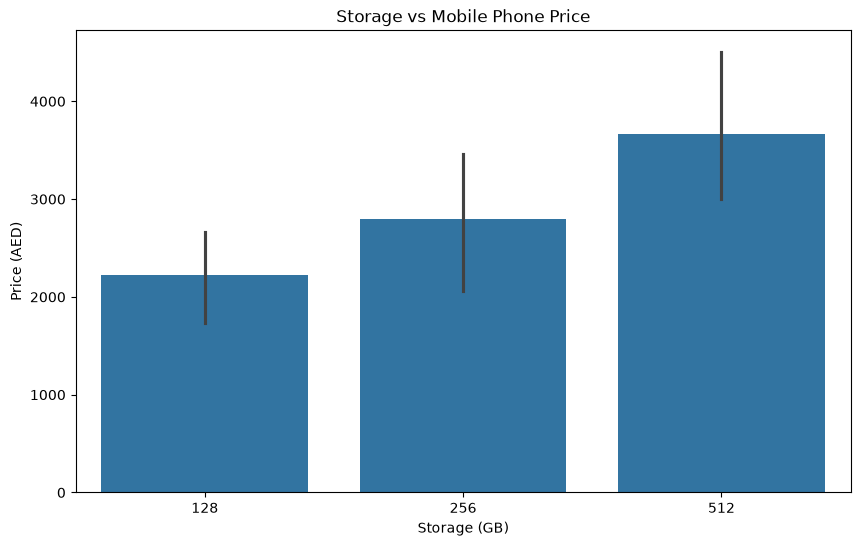

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="storage_gb",
    y="price"
)

plt.title("Storage vs Mobile Phone Price")
plt.xlabel("Storage (GB)")
plt.ylabel("Price (AED)")
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\storage_vs_price.png")
plt.show()

Price Box Plot

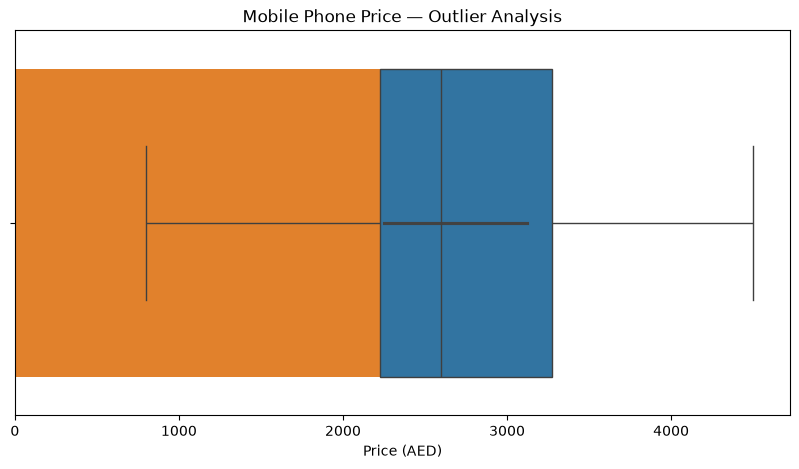

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="price"
)
sns.barplot( data=df,
    x="price")
plt.title("Mobile Phone Price — Outlier Analysis")
plt.xlabel("Price (AED)")
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\price_boxplot.png")
plt.show()

Box Plot by Brand

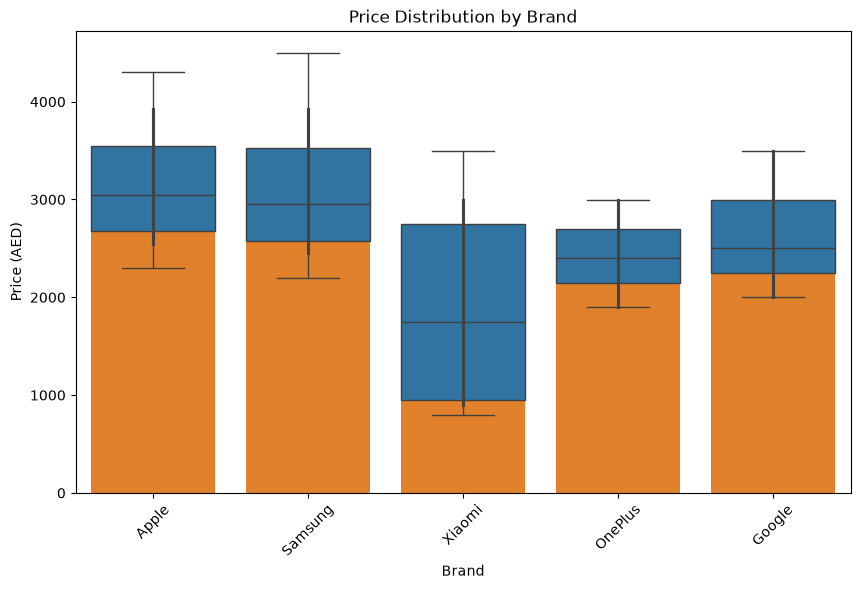

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="brand",
    y="price"
)
sns.barplot(data=df,
    x="brand",
    y="price")
plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (AED)")
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\price_boxplot.png")
plt.xticks(rotation=45)

plt.show()

In [ ]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 649.0
Upper bound: 4849.0


Calculate Correlation

In [ ]:
correlation = df.corr(numeric_only=True)

correlation

,price,ram_gb,storage_gb,rating
price,1.000000,0.385817,0.538451,0.941492
ram_gb,0.385817,1.000000,0.848608,0.380157
storage_gb,0.538451,0.848608,1.000000,0.578717
rating,0.941492,0.380157,0.578717,1.000000


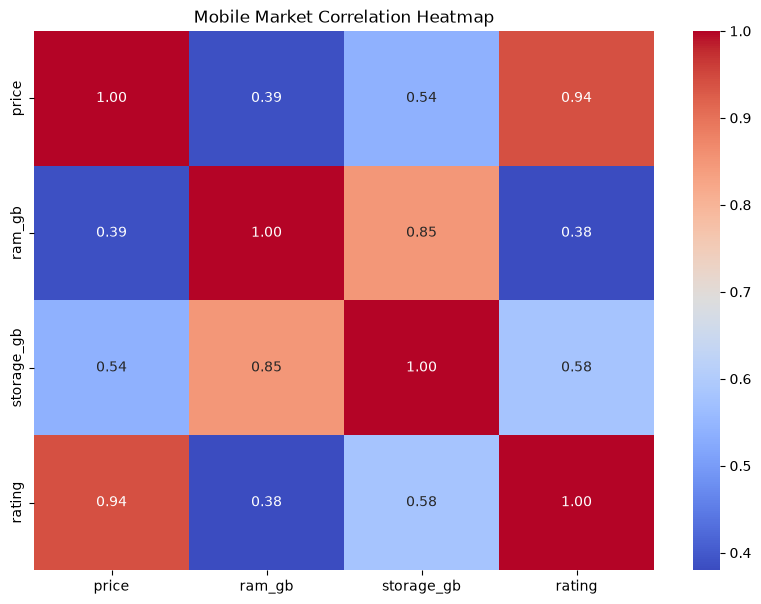

In [22]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mobile Market Correlation Heatmap")
plt.savefig("C:\\Users\\olaaz\\Documents\\AI Roadmap\\week8\\dubai-mobile-market-eda\\images\\correlation_heatmap.png")
plt.show()

## Key Findings

1. Mobile phone prices vary considerably across brands.

2. Higher-RAM phones generally tend to have higher prices.

3. Higher-storage phones generally tend to have higher prices.

4. Some phones may appear as potential price outliers and should
   be investigated rather than automatically removed.

5. Several numerical features show relationships with price,
   as demonstrated by the correlation matrix.

6. Correlation should not be interpreted as causation.